In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from math import sqrt

## Preliminary analysis:
**a) Import the datasets into the Python environment**

In [2]:
resturants_df = pd.read_csv('resturants.csv')
sales_df = pd.read_csv('sales.csv')
items_df = pd.read_csv('items.csv')

In [3]:
resturants_df.sample(6)

,id,name
3,4,Fou Cher
5,6,Surfs Up
0,1,Bob's Diner
4,5,Corner Cafe
2,3,Sweet Shack
1,2,Beachfront Bar


In [4]:
items_df.sample(6)

,id,store_id,name,kcal,cost
5,6,4,Fruity Frozen Cocktail,537,5.61
11,12,1,Fantastic Sweet Cola,478,4.87
62,63,5,Frozen Chocolate Cake,519,3.74
7,8,6,Amazing Trout with Vegetables Dinner,258,24.98
80,81,3,Fantastic Milky Smoothy,383,5.11
25,26,5,Blue Ribbon Lamb with Rolls Lunch,611,7.55


In [5]:
sales_df.sample(10)

,date,item_id,price,item_count
60459,2020-08-27,51,17.55,0.0
27745,2019-10-05,36,21.14,0.0
5458,2019-02-24,52,5.68,0.0
75201,2021-01-22,9,3.91,82.0
32335,2019-11-20,25,6.23,0.0
75450,2021-01-24,40,22.67,0.0
46636,2020-04-11,22,19.05,0.0
58306,2020-08-06,21,23.23,11.0
3212,2019-02-02,59,23.37,43.0
53630,2020-06-20,14,3.90,0.0


**b) Examine the dataset's shape and structure, and look out for any outlier**

***Check for missing values in all 3 dataframes***

In [6]:
# sales_df[(sales_df['item_count'] == 0.0 ) & (sales_df['price'] > 0.0)]

In [7]:
# sales_df.loc[(sales_df['item_count'] == 0.0 ) & (sales_df['price'] > 0.0), 'item_count'] = 1.0

In [8]:
# There cannot be 0 item_count sold, so lets remove these rows
sales_df = sales_df[sales_df['item_count'] != 0]

In [9]:
def report_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Reports missing values in a pandas DataFrame.

    :param df: The DataFrame to check for missing values.
    :type df: pd.DataFrame
    :return: A DataFrame containing the missing values and the corresponding percentages.
             Returns an empty DataFrame if no missing values are found.
    :rtype: pd.DataFrame
    """
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
    if not missing_data.empty:
        missing_data_percentage = (df.isnull().sum() / df.isnull().count() * 100).sort_values(ascending=False)
        missing_data = pd.DataFrame({'Missing Values': missing_data, 'Percentage': missing_data_percentage})
        return missing_data
    else:
        return pd.DataFrame(columns=['Missing Values', 'Percentage'])

In [10]:
# Check missing values in resturants_df
resturants_df_missing_values = report_missing_values(resturants_df)
resturants_df_missing_values

,Missing Values,Percentage


In [11]:
# Check missing values in items_df
items_df_missing_values = report_missing_values(items_df)
items_df_missing_values

,Missing Values,Percentage


In [12]:
# Check missing values in sales_df
sales_df_missing_values = report_missing_values(sales_df)
sales_df_missing_values

,Missing Values,Percentage


***Hence, There are no missing values in the 3 dataframes***

In [13]:
print(f"Shape of resturants_df dataset is {resturants_df.shape}")
print("\n")
print(f"Sturcture of resturants_df is \n {resturants_df.head()}")

Shape of resturants_df dataset is (6, 2)


Sturcture of resturants_df is 
    id            name
0   1     Bob's Diner
1   2  Beachfront Bar
2   3     Sweet Shack
3   4        Fou Cher
4   5     Corner Cafe


In [14]:
print(f"Shape of items_df dataset is {items_df.shape}")
print("\n")
print(f"Sturcture of items_df is \n {items_df.head()}")

Shape of items_df dataset is (100, 5)


Sturcture of items_df is 
    id  store_id                               name  kcal   cost
0   1         4                     Chocolate Cake   554   6.71
1   2         4  Breaded Fish with Vegetables Meal   772  15.09
2   3         1                  Sweet Fruity Cake   931  29.22
3   4         1    Amazing Steak Dinner with Rolls   763  26.42
4   5         5                          Milk Cake   583   6.07


In [15]:
print(f"Shape of sales_df dataset is {sales_df.shape}")
print("\n")
print(f"Sturcture of sales_df is \n {sales_df.head()}")

Shape of sales_df dataset is (23484, 4)


Sturcture of sales_df is 
          date  item_id  price  item_count
0  2019-01-01        3  29.22         2.0
1  2019-01-01        4  26.42        22.0
2  2019-01-01       12   4.87         7.0
3  2019-01-01       13   4.18        12.0
4  2019-01-01       16   3.21       136.0


***Check for Outliers***

In [16]:
def find_and_plot_outliers(df):
    outliers_dict = dict()

    # Find outliers for each numerical column
    for col in df.columns:
        if np.issubdtype(df[col].dtype, np.number):
            Q1 = np.percentile(df[col], 25)
            Q3 = np.percentile(df[col], 75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df[col][(df[col] < lower_bound) | (df[col] > upper_bound)]
            outliers_dict[col] = outliers

    # Plot box plots for each numerical column
    for col in outliers_dict.keys():
        sns.boxplot(x=df[col])
        plt.title(f'{col} Box Plot')
        plt.show()

    return outliers_dict

***Check for outliers in Restraunt data***

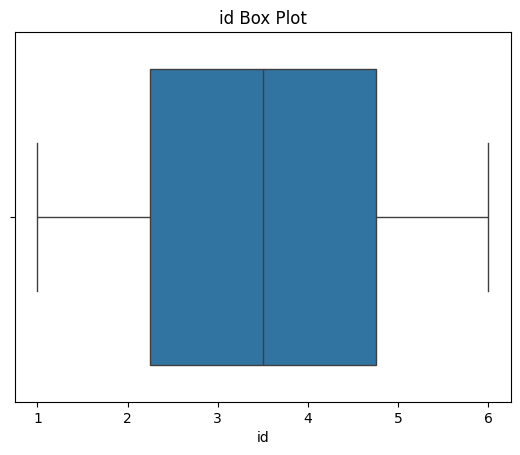

In [17]:
outliers_dict = find_and_plot_outliers(resturants_df)

***Hence, there are no outliers in Resturants data***

***Check for outliers in Items data***

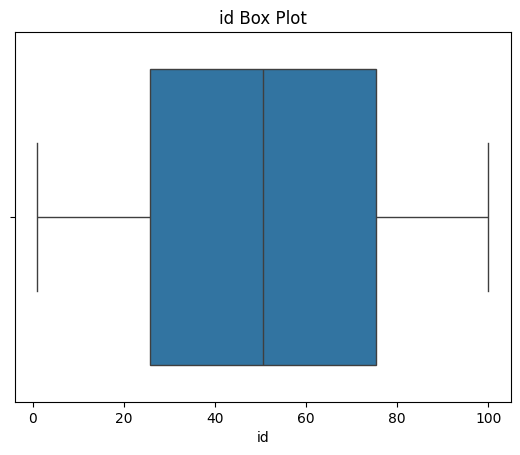

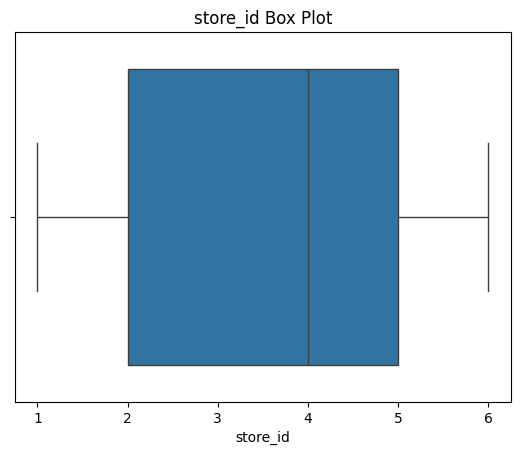

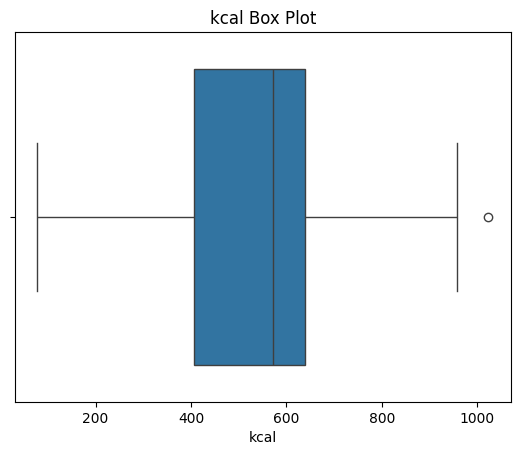

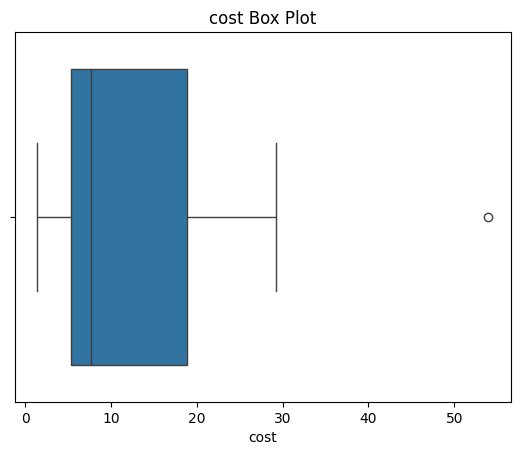

In [18]:
outliers_dict = find_and_plot_outliers(items_df)

***Hence, there are some outliers in kcal and cost data but we cannot consider this as outliers and remove them as Kcal and Cost are specific to the item and not historical data.***

***Check for outliers in Sales data***

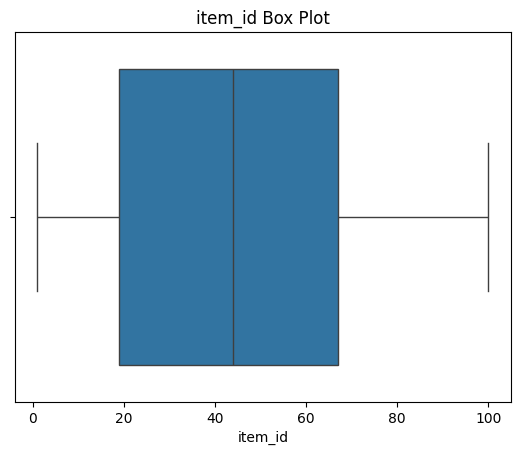

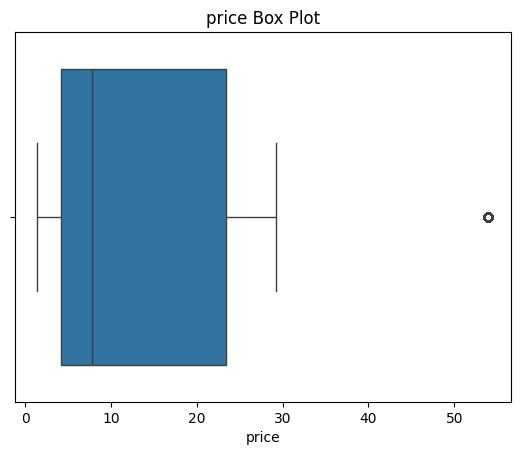

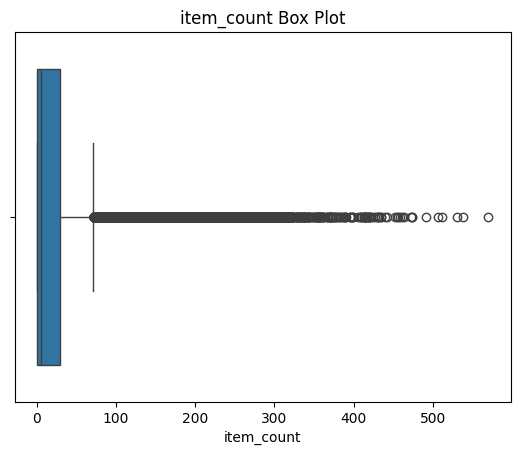

In [19]:
outliers_dict = find_and_plot_outliers(sales_df)

In [20]:
mean = sales_df['item_count'].mean()
median = sales_df['item_count'].median()
mode = sales_df['item_count'].mode()

print(f'Mean of item_count = {mean} \n Median of item_count = {median} \n Mode of item_count = {mode}')
print(f'Max item_count Value: {sales_df["item_count"].max()}')

Mean of item_count = 29.58554760688128 
 Median of item_count = 5.0 
 Mode of item_count = 0    1.0
Name: item_count, dtype: float64
Max item_count Value: 570.0


***Hence, we can see outliers only in Price and item_count columns but we cannot consider them as outliers.***
1. For the column "price", it is the unit price of each item which is specific to the item.
2. In case of column "item_count", it is the count of the items perchased in each record or the purchase. Mean (Average) of item_count = 29.59: This indicates that, on average, the number of items sold per transaction is approximately 29.59. However, the mean can be influenced by outliers, so it may not represent the typical item count accurately if there are extreme values in the data.
Median of item_count = 5.0: The median represents the middle value of the item counts when arranged in ascending order. In this case, it suggests that half of the transactions have 5 or fewer items, and the other half has more than 5 items. Hence we cannot consider high values of item_count as outliers.

**c) Merge the datasets into a single dataset that includes the date, item id, price, item count, item 
names, kcal values, store id, and store name**

In [21]:
merge1 = items_df.merge(resturants_df, left_on='store_id', right_on='id')
merge1

,id_x,store_id,name_x,kcal,cost,id_y,name_y
0,1,4,Chocolate Cake,554,6.71,4,Fou Cher
1,2,4,Breaded Fish with Vegetables Meal,772,15.09,4,Fou Cher
2,3,1,Sweet Fruity Cake,931,29.22,1,Bob's Diner
3,4,1,Amazing Steak Dinner with Rolls,763,26.42,1,Bob's Diner
4,5,5,Milk Cake,583,6.07,5,Corner Cafe
...,...,...,...,...,...,...,...
95,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93,5,Corner Cafe
96,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65,4,Fou Cher
97,98,2,Original Sweet Milky Soft Drink,579,5.00,2,Beachfront Bar
98,99,4,Frozen Tomato Soft Drink,423,5.32,4,Fou Cher


In [22]:
merge1 = merge1.drop('id_y', axis=1)
merge1

,id_x,store_id,name_x,kcal,cost,name_y
0,1,4,Chocolate Cake,554,6.71,Fou Cher
1,2,4,Breaded Fish with Vegetables Meal,772,15.09,Fou Cher
2,3,1,Sweet Fruity Cake,931,29.22,Bob's Diner
3,4,1,Amazing Steak Dinner with Rolls,763,26.42,Bob's Diner
4,5,5,Milk Cake,583,6.07,Corner Cafe
...,...,...,...,...,...,...
95,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93,Corner Cafe
96,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65,Fou Cher
97,98,2,Original Sweet Milky Soft Drink,579,5.00,Beachfront Bar
98,99,4,Frozen Tomato Soft Drink,423,5.32,Fou Cher


In [23]:
merge1.columns

Index(['id_x', 'store_id', 'name_x', 'kcal', 'cost', 'name_y'], dtype='object')

In [24]:
merge1 = merge1.rename(columns={'id_x': 'id_drop_later', 'name_x': 'item_name', 'name_y': 'store_name'})
merge1

,id_drop_later,store_id,item_name,kcal,cost,store_name
0,1,4,Chocolate Cake,554,6.71,Fou Cher
1,2,4,Breaded Fish with Vegetables Meal,772,15.09,Fou Cher
2,3,1,Sweet Fruity Cake,931,29.22,Bob's Diner
3,4,1,Amazing Steak Dinner with Rolls,763,26.42,Bob's Diner
4,5,5,Milk Cake,583,6.07,Corner Cafe
...,...,...,...,...,...,...
95,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93,Corner Cafe
96,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65,Fou Cher
97,98,2,Original Sweet Milky Soft Drink,579,5.00,Beachfront Bar
98,99,4,Frozen Tomato Soft Drink,423,5.32,Fou Cher


In [25]:
merge2 = merge1.merge(sales_df, left_on = 'id_drop_later', right_on='item_id')
merge2

,id_drop_later,store_id,item_name,kcal,cost,store_name,date,item_id,price,item_count
0,1,4,Chocolate Cake,554,6.71,Fou Cher,2020-01-23,1,6.71,1.0
1,2,4,Breaded Fish with Vegetables Meal,772,15.09,Fou Cher,2019-10-20,2,15.09,1.0
2,2,4,Breaded Fish with Vegetables Meal,772,15.09,Fou Cher,2019-12-16,2,15.09,1.0
3,2,4,Breaded Fish with Vegetables Meal,772,15.09,Fou Cher,2021-01-25,2,15.09,1.0
4,2,4,Breaded Fish with Vegetables Meal,772,15.09,Fou Cher,2021-05-17,2,15.09,1.0
...,...,...,...,...,...,...,...,...,...,...
23479,100,2,Awesome Vodka Cocktail,223,2.48,Beachfront Bar,2021-01-21,100,2.48,1.0
23480,100,2,Awesome Vodka Cocktail,223,2.48,Beachfront Bar,2021-03-21,100,2.48,1.0
23481,100,2,Awesome Vodka Cocktail,223,2.48,Beachfront Bar,2021-08-25,100,2.48,1.0
23482,100,2,Awesome Vodka Cocktail,223,2.48,Beachfront Bar,2021-09-13,100,2.48,1.0


Check the number of rows in Sales before and after merge to confirm that no data is missing

In [26]:
if merge2.shape[0] == sales_df.shape[0]:
    print("All rows are present")
else:
    print(f"{sales_df.shape[0] - merge2.shape[0]} rows are missing")

All rows are present


In [27]:
merge2.sample(9)

,id_drop_later,store_id,item_name,kcal,cost,store_name,date,item_id,price,item_count
19729,76,1,Amazing pork lunch,679,17.93,Bob's Diner,2019-02-10,76,17.93,19.0
17525,67,1,Sweet Lamb Cake,558,7.00,Bob's Diner,2021-02-26,67,7.00,8.0
12437,45,1,Awesome Fish with Vegetables Entree,227,23.43,Bob's Diner,2020-05-16,45,23.43,5.0
17616,67,1,Sweet Lamb Cake,558,7.00,Bob's Diner,2021-05-28,67,7.00,14.0
22195,90,1,Sweet Breaded Zucchini Cake,838,7.71,Bob's Diner,2019-06-25,90,7.71,4.0
5132,16,1,Frozen Milky Smoothy,284,3.21,Bob's Diner,2019-02-19,16,3.21,142.0
11492,42,2,Fantastic Milky Smoothy,318,2.91,Beachfront Bar,2021-01-07,42,2.91,1.0
18541,70,5,Pork with Bread Lunch,545,16.28,Corner Cafe,2020-12-09,70,16.28,1.0
11874,44,1,Milky Vegi Smoothy,374,5.50,Bob's Diner,2020-12-02,44,5.50,1.0


In [28]:
# Remove unnecessary column
merge2.drop('id_drop_later', axis=1, inplace=True)

In [29]:
# column price and cost are the same, so we can drop cost colunmn
merge2.drop('cost', axis=1, inplace=True)

In [30]:
merged_df = merge2
del merge2
merged_df.sample(6)

,store_id,item_name,kcal,store_name,date,item_id,price,item_count
15156,5,Lamb with Vegetables Meal,485,Corner Cafe,2019-04-12,58,13.66,1.0
9292,1,Fantastic Frozen Milky Cake,587,Bob's Diner,2021-02-18,25,6.23,3.0
17884,1,Blue Ribbon Fruity Milky Cake,652,Bob's Diner,2019-05-09,68,8.70,1.0
13064,3,Awesome Smoothy,78,Sweet Shack,2019-02-04,49,1.39,3.0
6119,1,Strawberry Smoothy,145,Bob's Diner,2020-02-28,19,2.89,245.0
714,1,Sweet Fruity Cake,931,Bob's Diner,2021-03-06,3,29.22,4.0


## Exploratory data analysis:

**a) Examine the overall date wise sales to understand the pattern**

In [31]:
# Calculate the sale amount
merged_df['Amount'] = merged_df['item_count']*merged_df['price']

In [32]:
# Sort data by the date of sale
merged_df['date_formatted'] = pd.to_datetime(merged_df['date'])
merged_df = merged_df.sort_values(by='date_formatted')

In [33]:
date_wise_sales = merged_df.groupby('date_formatted')['Amount'].sum()
date_wise_sales

date_formatted
2019-01-01    4023.00
2019-01-02    3074.69
2019-01-03    4062.71
2019-01-04    5006.81
2019-01-05    4927.53
               ...   
2021-12-27    1867.71
2021-12-28    3426.50
2021-12-29    3715.39
2021-12-30    5266.27
2021-12-31    8287.81
Name: Amount, Length: 1096, dtype: float64

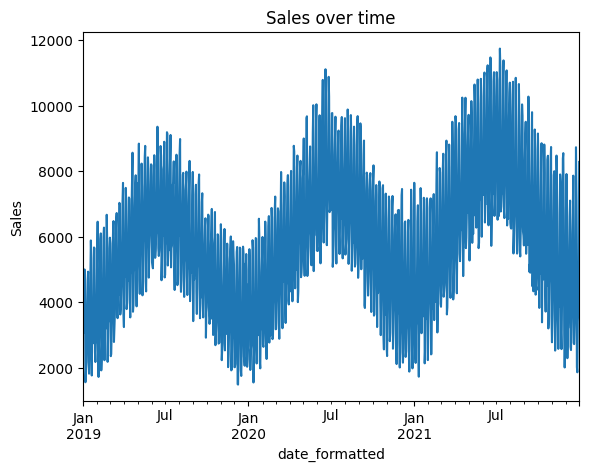

In [34]:
date_wise_sales.plot(kind='line')
plt.title('Sales over time')
plt.xlabel('date_formatted')
plt.ylabel('Sales')
plt.show()

***Hence the Sale is lowest in January and at its peak in July. Every year the maximum sales are increasing gradually***

**b) Find out how sales fluctuate across different days of the week**

In [35]:
merged_df['day_of_week'] = merged_df['date_formatted'].dt.day_name()
merged_df['month'] = merged_df['date_formatted'].dt.month_name()
merged_df['year'] = merged_df['date_formatted'].dt.year

merged_df.head()

,store_id,item_name,kcal,store_name,date,item_id,price,item_count,Amount,date_formatted,day_of_week,month,year
2785,1,Fantastic Sweet Cola,478,Bob's Diner,2019-01-01,12,4.87,7.0,34.09,2019-01-01,Tuesday,January,2019
22068,1,Sweet Breaded Zucchini Cake,838,Bob's Diner,2019-01-01,90,7.71,2.0,15.42,2019-01-01,Tuesday,January,2019
16743,1,Sweet Lamb Cake,558,Bob's Diner,2019-01-01,67,7.00,23.0,161.00,2019-01-01,Tuesday,January,2019
14049,1,Sea Bass with Vegetables Dinner,613,Bob's Diner,2019-01-01,56,28.75,18.0,517.50,2019-01-01,Tuesday,January,2019
5696,1,Strawberry Smoothy,145,Bob's Diner,2019-01-01,19,2.89,108.0,312.12,2019-01-01,Tuesday,January,2019


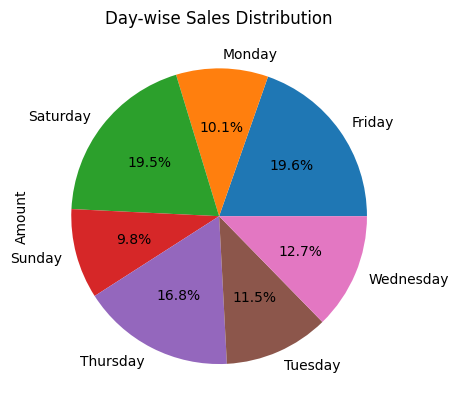

In [36]:
weekday_sales = merged_df.groupby('day_of_week')['Amount'].sum()
weekday_sales.plot(kind='pie', autopct='%1.1f%%', x='day_of_week', y='Amount')
plt.title('Day-wise Sales Distribution')
plt.show()

***Hence, the Sale is highest(19.6%) on Friday and lowest(9.8%) on Sunday***

**c) Look for any noticeable trends in the sales data for different months of the year**

In [37]:
# merged_df['month'] = merged_df['date_formatted'].dt.month_name()
# merged_df['year'] = merged_df['date_formatted'].dt.year

grouped_data = merged_df.groupby(['year', 'month'])['Amount'].sum()

grouped_data = pd.DataFrame(grouped_data)
grouped_data.reset_index(inplace=True)

# Convert 'month' column to categorical data type to ensure correct sorting
grouped_data['month'] = pd.Categorical(grouped_data['month'], categories=[
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'], ordered=True)

# Sort the DataFrame by 'year' and 'month'
grouped_data = grouped_data.sort_values(by=['year', 'month'])

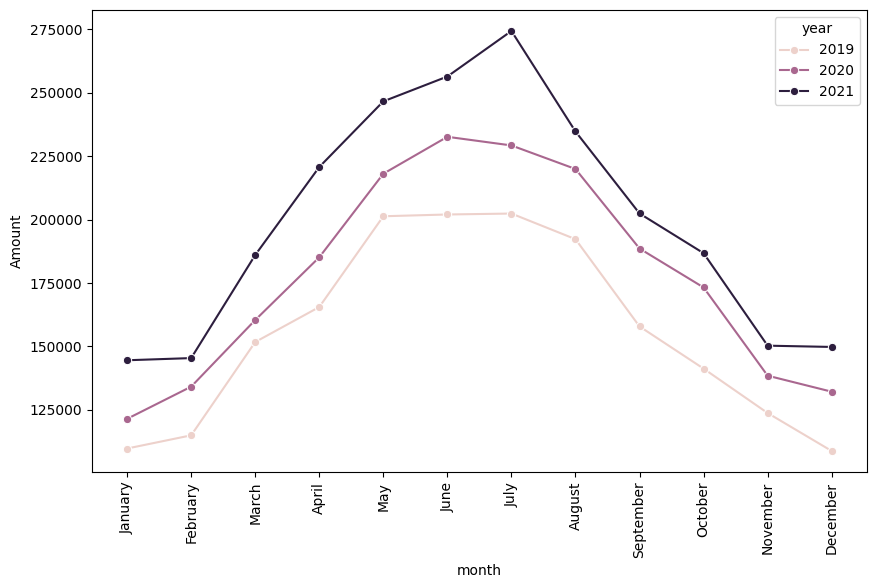

In [38]:
plt.figure(figsize=(10, 6))
sns.lineplot(hue='year', data=grouped_data, x='month', y='Amount', marker='o')
plt.xticks(rotation=90)
plt.show()

***From the above plot we can see that follwing pattern:***
1. Overall sales are increasing year on year.
2. Sales are the highest between June and July.
3. Sales are lowest near year ending.
4. In 2021, for the first time in 3 years sales fell in February instaed of increasing.
5. In 2020, Sales reduced in July instead of increasing.
6. In 2021, Sales increased by a lot in July and increased instead or redusing in December.

**d) Examine the sales distribution across different quarters averaged over the years. Identify any noticeable patterns**

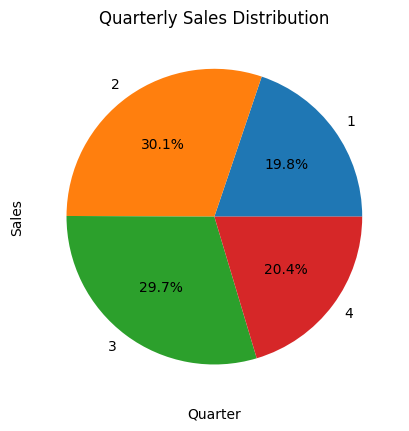

In [39]:
merged_df['quarter'] = merged_df['date_formatted'].dt.quarter

quarter_sales = merged_df.groupby('quarter')['Amount'].sum()

quarter_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Quarterly Sales Distribution')
plt.xlabel('Quarter')
plt.ylabel('Sales')
plt.show()

***Hence, Sales are highest (30.1%) in the 2nd Quarter of the year and lowest(19.8%) in the 1st Quarter***

**e) Compare the performances of the different restaurants. Find out which restaurant had the most sales and look at the sales for each restaurant across different years, months, and days.**

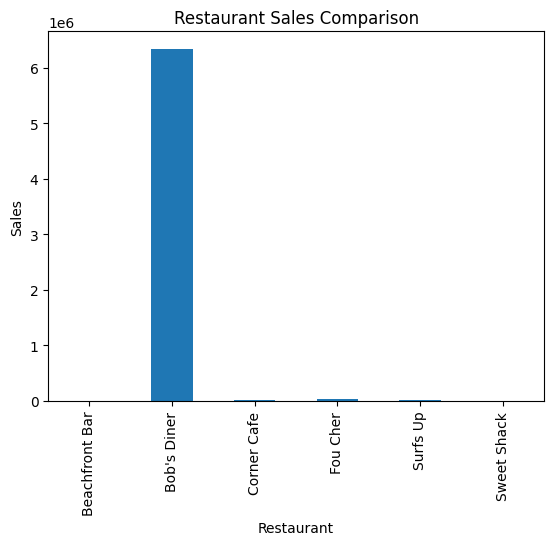

Sales Distribution for restaurant: "Bob's Diner"


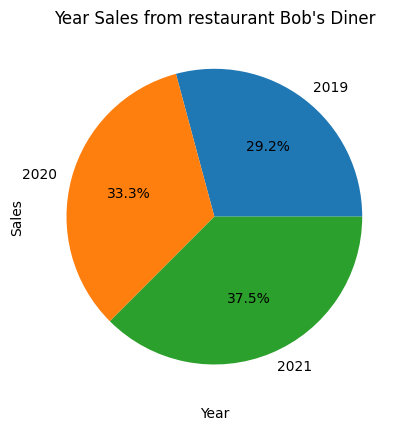

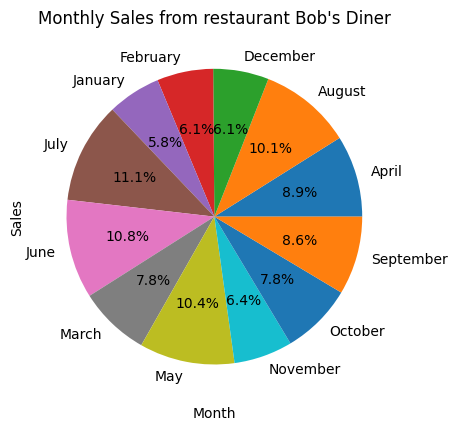

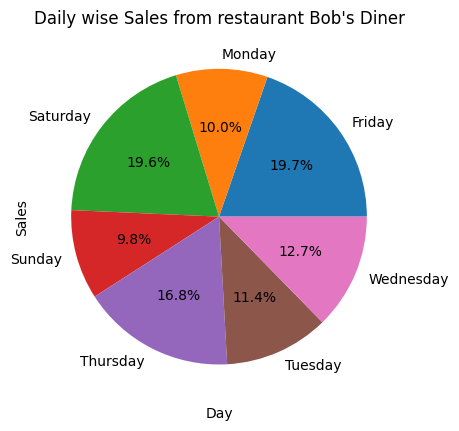

Sales Distribution for restaurant: "Corner Cafe"


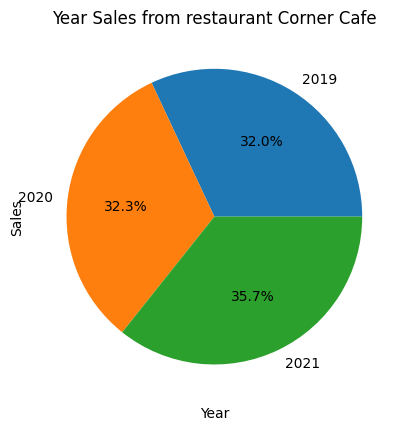

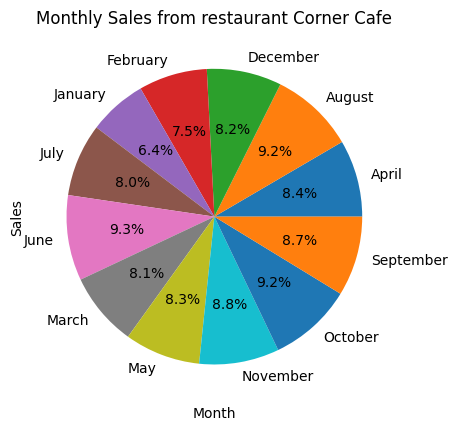

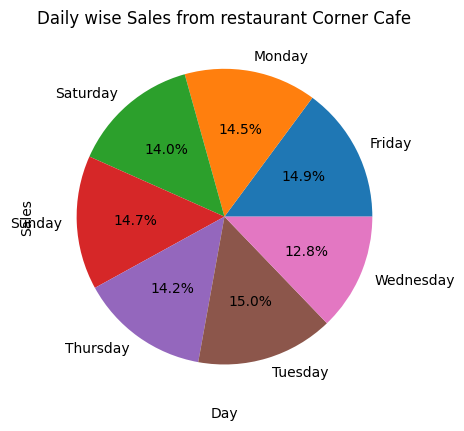

Sales Distribution for restaurant: "Surfs Up"


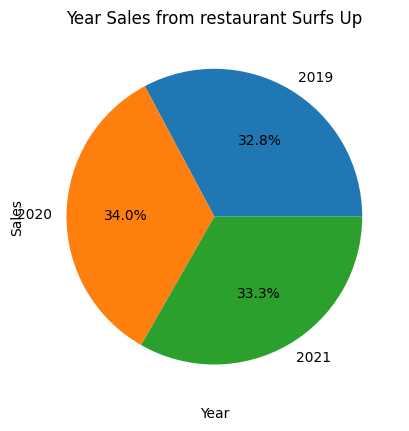

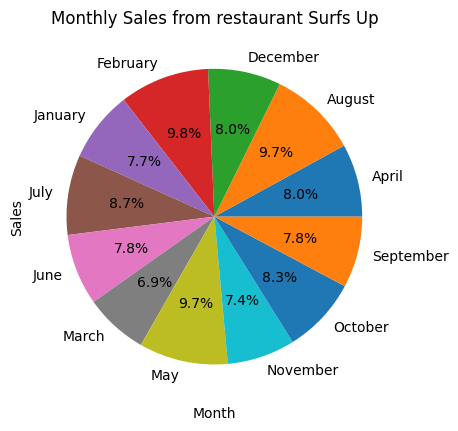

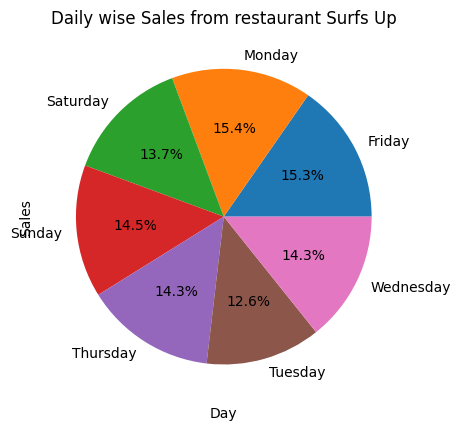

Sales Distribution for restaurant: "Fou Cher"


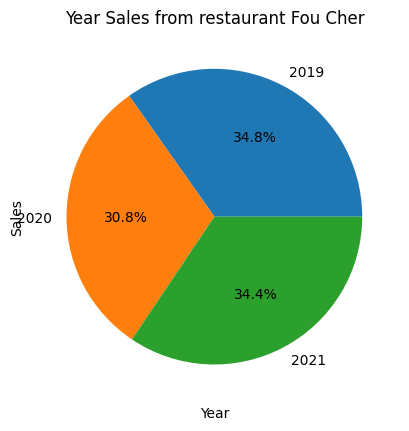

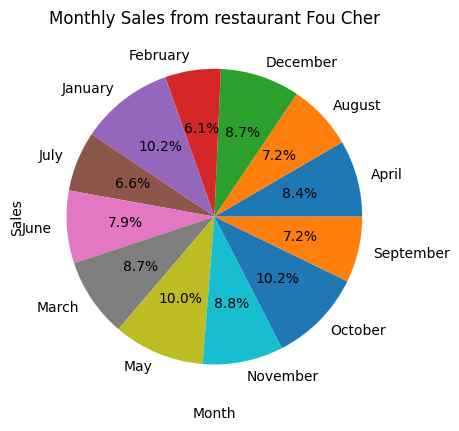

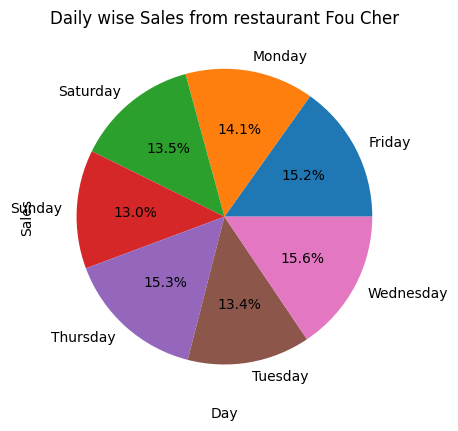

Sales Distribution for restaurant: "Beachfront Bar"


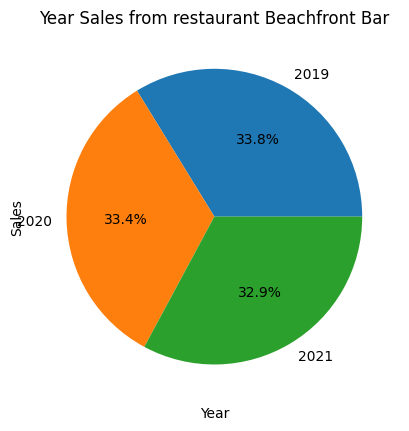

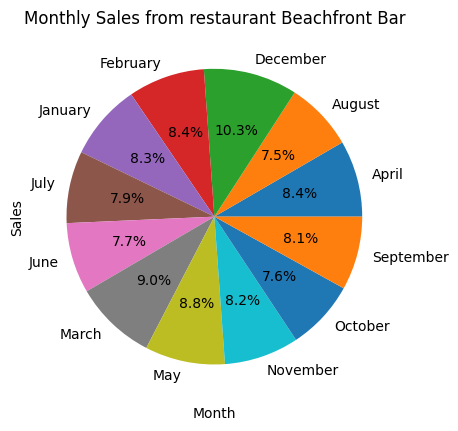

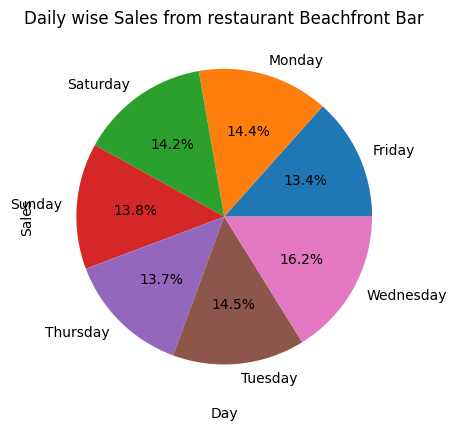

Sales Distribution for restaurant: "Sweet Shack"


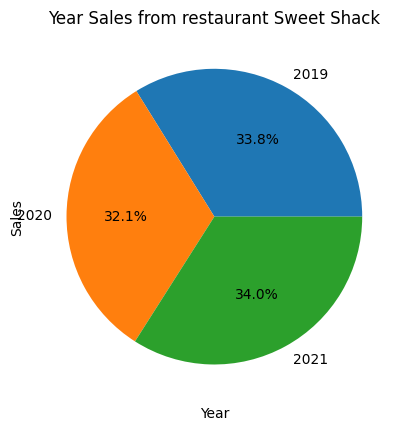

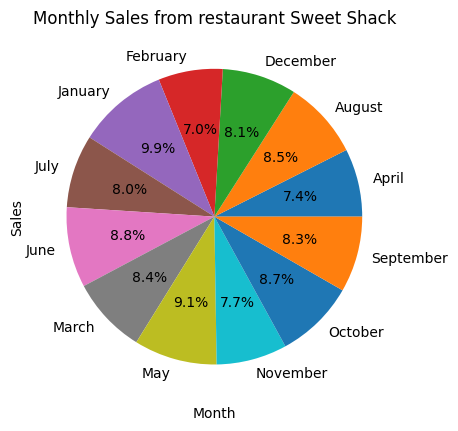

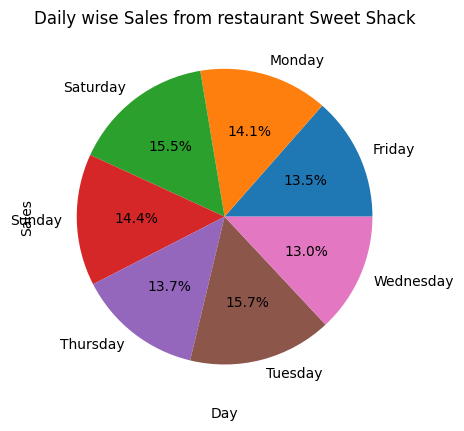

In [40]:
store_sales = merged_df.groupby('store_name')['Amount'].sum()
store_sales.plot(kind='bar')
plt.title('Restaurant Sales Comparison')
plt.xlabel('Restaurant')
plt.ylabel('Sales')
plt.show()

merged_df['year'] = merged_df['date_formatted'].dt.year

def store_sales_charts(store_name):
    print(f'Sales Distribution for restaurant: "{store_name}"')
    store_data = merged_df[merged_df['store_name'] == store_name]
    # Yearly sale Pie
    store_yearly = store_data.groupby('year')['Amount'].sum()
    store_yearly.plot(kind='pie', autopct='%1.1f%%')
    plt.title(f'Year Sales from restaurant {store_name}')
    plt.xlabel('Year')
    plt.ylabel('Sales')
    plt.show()

    # Monthly Sales Pie
    store_yearly = store_data.groupby('month')['Amount'].sum()
    store_yearly.plot(kind='pie', autopct='%1.1f%%')
    plt.title(f'Monthly Sales from restaurant {store_name}')
    plt.xlabel('Month')
    plt.ylabel('Sales')
    plt.show()

    # Daily sales Pie
    store_yearly = store_data.groupby('day_of_week')['Amount'].sum()
    store_yearly.plot(kind='pie', autopct='%1.1f%%')
    plt.title(f'Daily wise Sales from restaurant {store_name}')
    plt.xlabel('Day')
    plt.ylabel('Sales')
    plt.show()


all_store_names = merged_df['store_name'].unique()

for store in all_store_names:
    store_sales_charts(store)

***Hence Bob's Diner has the highest Sales out of all the stores***

**f) Identify the most popular items overall and the stores where they are being sold. Also, find out the most popular item at each store**

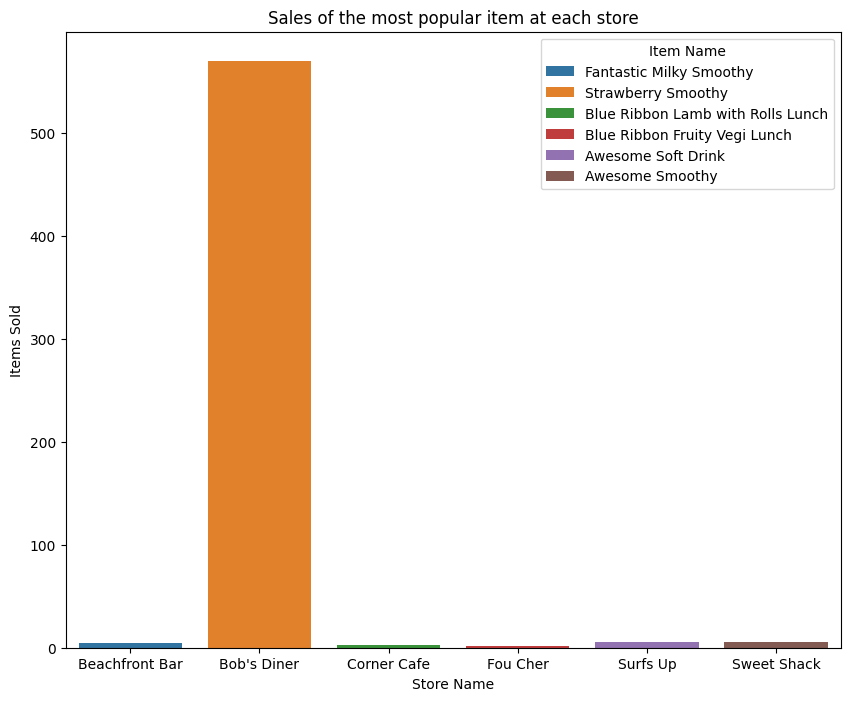

In [41]:
# Most popular item overall
popular_item = merged_df.groupby('item_name')['item_count'].sum().idxmax()

# Most popular items at each store
popular_item_at_each_store = merged_df.loc[
    merged_df.groupby('store_name')['item_count'].idxmax(), ['store_name', 'item_name', 'item_count']]

# Bar graph for the most popular item overall
most_popular_item_df = merged_df[merged_df['item_name'] == popular_item]
most_popular_item_sales = most_popular_item_df.groupby('store_name')['item_count'].sum()

# plt.figure(figsize=(10, 8))
# sns.barplot(x=most_popular_item_sales.index, y=most_popular_item_sales.values)
# plt.title('Sales of the most popular item at each store')
# plt.xlabel('Store Name')
# plt.ylabel('Items sold')
# plt.show()

# Bar graph for most popular items at each store
plt.figure(figsize=(10, 8))
sns.barplot(x=popular_item_at_each_store['store_name'], y=popular_item_at_each_store['item_count'],
            hue=popular_item_at_each_store['item_name'])
plt.title('Sales of the most popular item at each store')
plt.xlabel('Store Name')
plt.ylabel('Items Sold')
plt.legend(title='Item Name')
plt.show()

1. Hence, the most popular item among all restaurants is Strawberry Smoothy and it is sold at Bob's Diner.
2. Most popular item at Beachfront Bar is Fantastic Milky Smoothy.
3. Most popular item at Corner Cafe is Blue Ribbon Lamb with Rolls Lunch.
4. Most popular item at Fou Cher is Blue Ribbon Fruity with Vegi Lunch.
5. Most popular item at Surfs Up is Awesome Soft Drink.
6. Most popular item at Sweet Shack is Awesome Smoothy.

**g) Determine if the store with the highest sales volume is also making the most money per day**

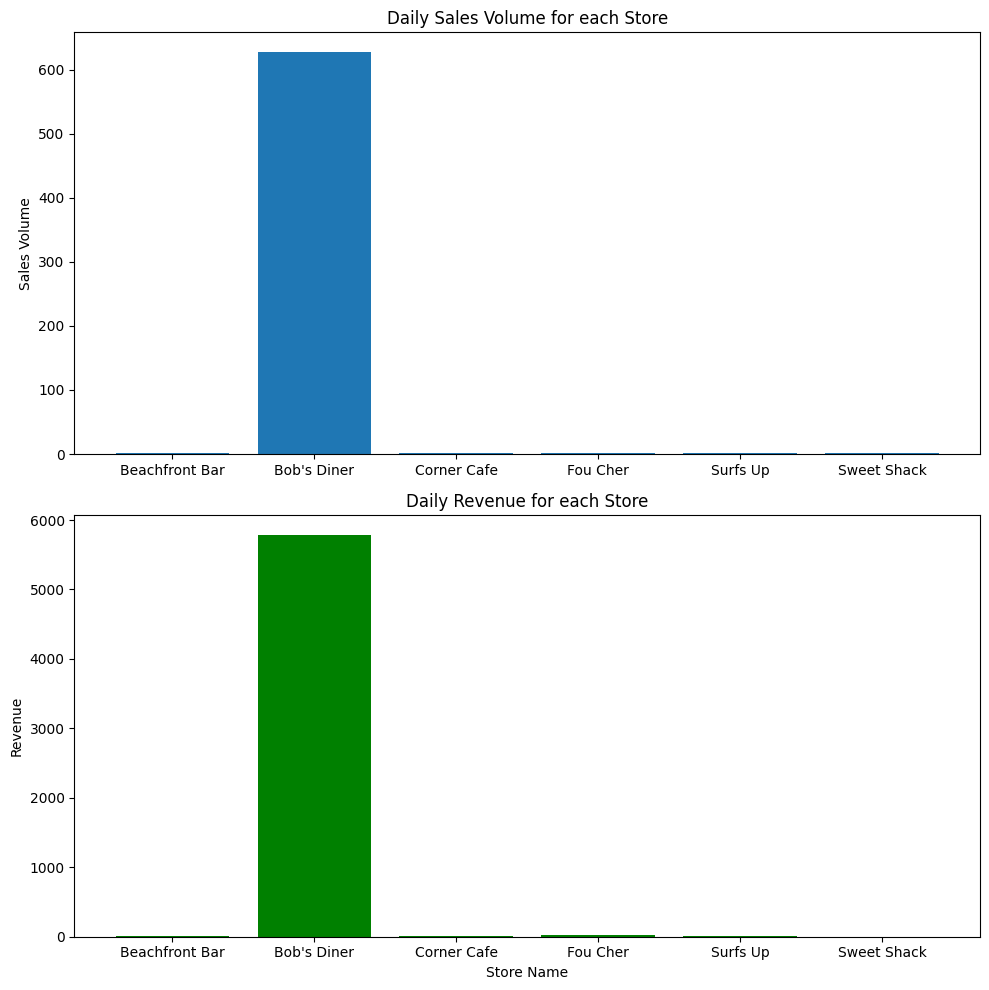

In [42]:
daily_volume = merged_df.groupby('store_name')['item_count'].sum() / merged_df[
    'date'].nunique()
daily_profit = (merged_df.groupby('store_name')['Amount'].sum() / merged_df[
    'date'].nunique())

# Create subplot for two diagrams
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

ax[0].bar(daily_volume.index, daily_volume)
ax[0].set_title('Daily Sales Volume for each Store')
ax[0].set_ylabel('Sales Volume')

ax[1].bar(daily_profit.index, daily_profit, color='green')
ax[1].set_title('Daily Revenue for each Store')
ax[1].set_xlabel('Store Name')
ax[1].set_ylabel('Revenue')

plt.tight_layout()
plt.show()

***Hence, the Store having maximum sales volume is also making the most money per day i.e Bob's Diner***

**h) Identify the most expensive item at each restaurant and find out its calorie count**

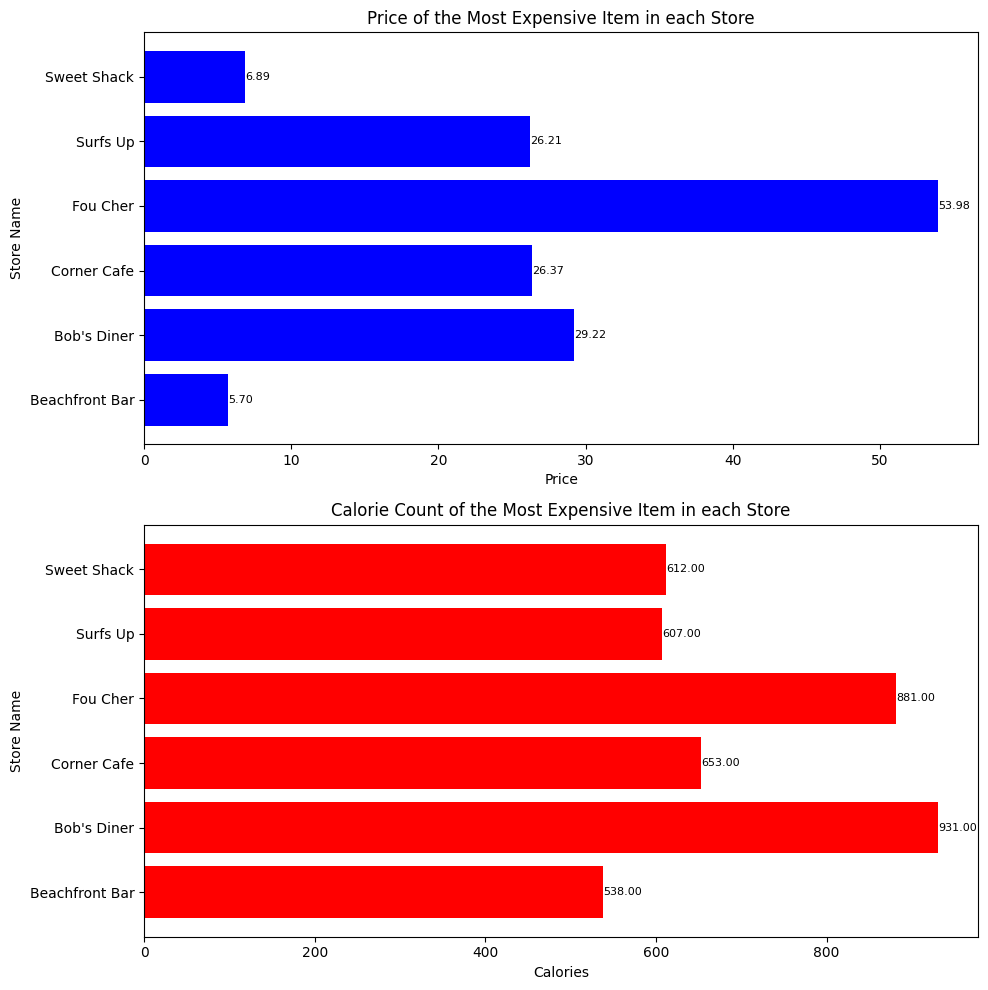

The list of most expensive items at each restraunt and their price is at follows: 



,index,store_name,item_name,price,kcal
0,16494,Beachfront Bar,Sweet Vegi Soft Drink,5.70,538
1,5,Bob's Diner,Sweet Fruity Cake,29.22,931
2,13918,Corner Cafe,Pike Lunch,26.37,653
3,20903,Fou Cher,Blue Ribbon Fruity Vegi Lunch,53.98,881
4,9712,Surfs Up,Steak Meal,26.21,607
5,12983,Sweet Shack,Blue Ribbon Milky Cake,6.89,612


In [43]:
# Find the most expensive item at each store and its calorie count
most_expensive_item = \
    merged_df.loc[merged_df.groupby('store_name')['price'].idxmax()][
        ['store_name', 'item_name', 'price', 'kcal']]

# Create subplot for two diagrams
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Bar plot for comparing prices
bars1 = ax1.barh(most_expensive_item.store_name, most_expensive_item.price, color='blue')
ax1.set_title('Price of the Most Expensive Item in each Store')
ax1.set_xlabel('Price')
ax1.set_ylabel('Store Name')

# Add frequency count to each bar
for bar in bars1:
    yval = bar.get_y() + bar.get_height() / 2
    xval = bar.get_width()
    ax1.text(xval, yval, f'{xval:.2f}', va='center', ha='left', fontsize=8)

# Bar plot for comparing calorie counts
bars2 = ax2.barh(most_expensive_item.store_name, most_expensive_item.kcal, color='red')
ax2.set_title('Calorie Count of the Most Expensive Item in each Store')
ax2.set_xlabel('Calories')
ax2.set_ylabel('Store Name')

# Add frequency count to each bar
for bar in bars2:
    yval = bar.get_y() + bar.get_height() / 2
    xval = bar.get_width()
    ax2.text(xval, yval, f'{xval:.2f}', va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.show()

print("The list of most expensive items at each restraunt and their price is at follows: \n")
most_expensive_item.reset_index()


## Forecasting using machine learning algorithms
**a) Build and compare linear regression, random forest, and XGBoost models for predictions**

a.1) Generate necessary features for the development of these models, like day of the week, 
quarter of the year, month, year, day of the month and so on

In [44]:
# merged_df.sample(10)

In [45]:
merged_df['date'] = pd.to_datetime(merged_df['date'])

# Create additional features
merged_df['day_of_week_num'] = merged_df['date'].dt.dayofweek
merged_df['quarter'] = merged_df['date'].dt.quarter
merged_df['month'] = merged_df['date'].dt.month
merged_df['year'] = merged_df['date'].dt.year
merged_df['day_of_month'] = merged_df['date'].dt.day

a.2) Use the data from the last six months as the testing data

In [46]:
# Get the last date for 6 months ago
split_date = merged_df['date'].max() - pd.DateOffset(months=6)

# Train data - everything before split_date
train = merged_df.loc[merged_df['date'] <= split_date]

# Test data - the last 6 months
test = merged_df.loc[merged_df['date'] > split_date]

In [47]:
target = 'item_count'
features = ['store_id', 'item_id', 'day_of_week_num', 'quarter', 'month', 'year', 'day_of_month']
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [48]:

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

# XGBoost
xgb = XGBRegressor(n_estimators=100)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

a.3) Compute the root mean square error (RMSE) values for each model to compare their 
performances

In [49]:
models = [lr, rf, xgb]
model_names = ['Linear Regression', 'Random Forest', 'XGBoost']

for model, name in zip(models, model_names):
    y_pred = model.predict(X_test)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    print(f'{name} RMSE: {rmse}')

Linear Regression RMSE: 56.89151455368373
Random Forest RMSE: 27.868700619202908
XGBoost RMSE: 23.931232843150575


a.4) Use the best-performing models to make a forecast for the next year 

In [50]:
# Use the model with the best RMSE
best_model = models[np.argmin([sqrt(mean_squared_error(y_test, model.predict(X_test))) for model in models])]

# Generate the features for the next year
next_year = pd.DataFrame(pd.date_range(start='2023-01-01', end='2023-12-31', freq='D'), columns=['date'])

next_year['day_of_week_num'] = next_year['date'].dt.dayofweek
next_year['quarter'] = next_year['date'].dt.quarter
next_year['month'] = next_year['date'].dt.month
next_year['year'] = next_year['date'].dt.year
next_year['day_of_month'] = next_year['date'].dt.day

predictions_df = pd.DataFrame()

# Iterate over each unique store and item ID
for store_id in merged_df['store_id'].unique():
    for item_id in merged_df['item_id'].unique():
        # Generate future dates features values
        next_year['store_id'] = store_id
        next_year['item_id'] = item_id
        # Use the best model to make predictions
        next_year['predicted'] = best_model.predict(next_year[features])
        # Append to the final dataframe
        predictions_df = pd.concat([predictions_df, next_year])

# Reset index for the final DataFrame
predictions_df.reset_index(drop=True, inplace=True)
print(type(best_model).__name__)

XGBRegressor


In [78]:
predictions_df.sample(5)

,date,day_of_week_num,quarter,month,year,day_of_month,store_id,item_id,predicted
26369,2023-03-31,4,1,3,2023,31,1,10,13.137761
185379,2023-11-21,1,4,11,2023,21,3,44,1.663728
83594,2023-01-10,1,1,1,2023,10,6,24,2.835234
42174,2023-07-19,2,3,7,2023,19,5,89,1.435056
199208,2023-10-11,2,4,10,2023,11,3,9,63.274807


## Forecasting using deep learning algorithms
Creating Synthetic data for 12 months

Define the train and test series 

• Generate synthetic data for the last 12 months 

• Build and train an LSTM model 

• Use the model to make predictions for the test data 

Calculate the mean absolute percentage error (MAPE) and comment on the model's performance

In [51]:
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_percentage_error

# Function to generate synthetic daily sales data for 12 months
def generate_synthetic_sales_data():
    # Generate synthetic data (example: sinusoidal pattern with noise)
    time = np.arange(0, 365 * 12)  # 12 months of daily data
    sales_data = 1000 * np.sin(2 * np.pi * time / 365) + np.random.normal(0, 200, len(time))
    return sales_data

# Function to prepare data for LSTM
def prepare_data(series, time_steps):
    X, y = [], []
    for i in range(len(series) - time_steps):
        X.append(series[i:(i + time_steps)])
        y.append(series[i + time_steps])
    return np.array(X), np.array(y)

# Generate synthetic daily sales data
sales_data = generate_synthetic_sales_data()

# Define time steps (e.g., past 30 days for prediction)
time_steps = 30

# Prepare data for LSTM
X, y = prepare_data(sales_data, time_steps)

# Reshape input to be [samples, time steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Build LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X, y, epochs=1000, batch_size=64)

# Make predictions for the next month (using the last month as input)
last_month_data = sales_data[-time_steps:]
X_test = np.reshape(last_month_data, (1, time_steps, 1))
next_month_predictions = model.predict(X_test)

# Evaluate model performance (MAPE)
actual_next_month_data = sales_data[-1]  # Actual sales data for the next month
mape = mean_absolute_percentage_error([actual_next_month_data], next_month_predictions)
print("MAPE for the next month:", mape)


Epoch 1/1000
68/68 [==============================] - 6s 12ms/step - loss: 537075.3750
Epoch 2/1000
68/68 [==============================] - 1s 11ms/step - loss: 528608.0625
Epoch 3/1000
68/68 [==============================] - 1s 9ms/step - loss: 522796.7812
Epoch 4/1000
68/68 [==============================] - 1s 8ms/step - loss: 517775.1250
Epoch 5/1000
68/68 [==============================] - 1s 9ms/step - loss: 512795.8438
Epoch 6/1000
68/68 [==============================] - 1s 8ms/step - loss: 507987.2188
Epoch 7/1000
68/68 [==============================] - 1s 8ms/step - loss: 503132.5625
Epoch 8/1000
68/68 [==============================] - 1s 8ms/step - loss: 498634.7500
Epoch 9/1000
68/68 [==============================] - 1s 8ms/step - loss: 494215.7188
Epoch 10/1000
68/68 [==============================] - 1s 8ms/step - loss: 489746.5625
Epoch 11/1000
68/68 [==============================] - 1s 8ms/step - loss: 485502.2188
Epoch 12/1000
68/68 [=============================

In [52]:
# Generate synthetic daily sales data for testing
test_sales_data = generate_synthetic_sales_data()

# Prepare test data for LSTM
X_test, y_test = prepare_data(test_sales_data, time_steps)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Make predictions on the test data
test_predictions = model.predict(X_test)

# Calculate MAPE for testing data
test_mape = mean_absolute_percentage_error(y_test, test_predictions)
print("MAPE on testing data:", test_mape)

136/136 [==============================] - 1s 4ms/step
MAPE on testing data: 1.1137563345713835


***The MAPE score is 1.11 which is a very good score and it indicates a highly accurate model.***

 Develop another model using the entire series for training, and use it to forecast for the next three 
months


In [53]:
import matplotlib.pyplot as plt

# Prepare data using the entire series
X_full, y_full = prepare_data(sales_data, time_steps)
X_full = np.reshape(X_full, (X_full.shape[0], X_full.shape[1], 1))

# Build LSTM model for full training data
model_full = Sequential()
model_full.add(LSTM(units=50, return_sequences=True, input_shape=(X_full.shape[1], 1)))
model_full.add(LSTM(units=50))
model_full.add(Dense(units=1))
model_full.compile(optimizer='adam', loss='mean_squared_error')

# Train the model using the entire series
model_full.fit(X_full, y_full, epochs=1000, batch_size=32)



Epoch 1/1000
136/136 [==============================] - 4s 10ms/step - loss: 532029.3750
Epoch 2/1000
136/136 [==============================] - 1s 9ms/step - loss: 519522.0000
Epoch 3/1000
136/136 [==============================] - 1s 9ms/step - loss: 509522.0312
Epoch 4/1000
136/136 [==============================] - 1s 9ms/step - loss: 500238.5938
Epoch 5/1000
136/136 [==============================] - 1s 9ms/step - loss: 491430.1875
Epoch 6/1000
136/136 [==============================] - 1s 9ms/step - loss: 483001.5625
Epoch 7/1000
136/136 [==============================] - 1s 9ms/step - loss: 474978.6250
Epoch 8/1000
136/136 [==============================] - 1s 10ms/step - loss: 466853.3125
Epoch 9/1000
136/136 [==============================] - 1s 9ms/step - loss: 458655.3438
Epoch 10/1000
136/136 [==============================] - 1s 9ms/step - loss: 451063.8750
Epoch 11/1000
136/136 [==============================] - 1s 9ms/step - loss: 443625.5938
Epoch 12/1000
136/136 [=====

(1, 30, 1)
1/1 [==============================] - 0s 21ms/step
(90,)


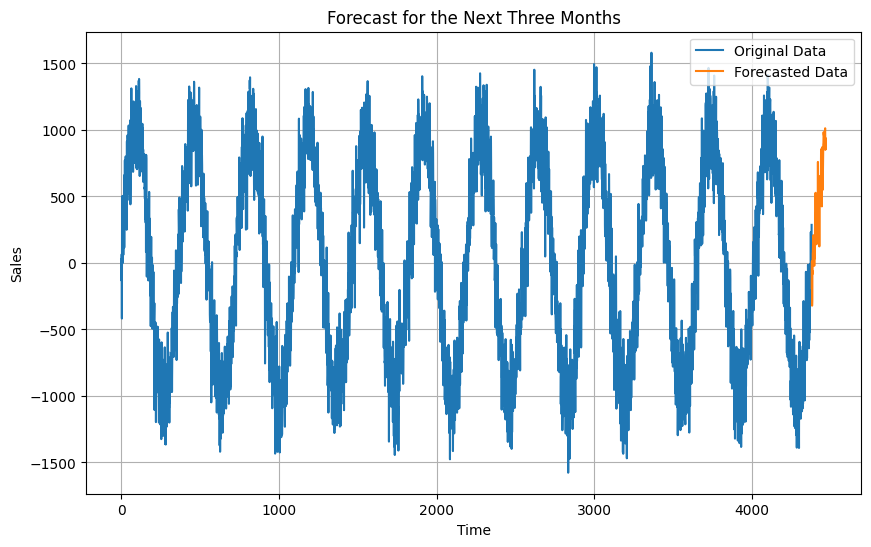

In [54]:
# Prepare data for the next three months
next_three_months_data = generate_synthetic_sales_data()[-time_steps:]

X_next = np.reshape(next_three_months_data, (1, len(next_three_months_data), 1))  # Adding a batch dimension
print(X_next.shape)

# Make predictions for the next three months
next_three_months_predictions = []
current_input = X_next.copy()
for _ in range(3 * 30):  # Predict for each day in the next three months
    prediction = model_full.predict(current_input)
    next_three_months_predictions.append(prediction[0, 0])  # Append the predicted value
    # Shift the input data by one step for the next prediction
    current_input[:, :-1, :] = current_input[:, 1:, :]
    current_input[:, -1, 0] = prediction[0, 0]  # Update the last value with the prediction

# Convert predictions to numpy array
next_three_months_predictions = np.array(next_three_months_predictions)

# Plot the original data and the forecasted values
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(sales_data)), sales_data, label='Original Data')

# Generate x values for the forecasted data
x_forecast = np.arange(len(sales_data), len(sales_data) + len(next_three_months_predictions))
print(x_forecast.shape)

# Plot the forecasted data
plt.plot(x_forecast, next_three_months_predictions, label='Forecasted Data')

plt.xlabel('Time')
plt.ylabel('Sales')
plt.title('Forecast for the Next Three Months')
plt.legend()
plt.grid(True)
plt.show()


***As per the above graph, we can see the sales will continue to increase in the upcoming 30 days.***